<a href="https://colab.research.google.com/github/joacoDG/deep-learning-ev1/blob/main/evaluacion_1_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN N°1 FUNDAMENTOS DE DEEP LEARNING
## Objetivos y problema a resolver

Diseñar, entrenar y comparar un modelo de red neuronal profunda para la clasificación de imágenes del dataset Fashion-MNIST, evaluando cómo la elección de funciones de activación influye en la convergencia y desempeño del modelo.

El problema que abordamos es entender cómo decisiones de diseño en redes neuronales, específicamente la función de activación, afectan el rendimiento en tareas de clasificación de imágenes.

## Carga y Preprocesamiento de Datos (Desde Archivo Local)

Para este proyecto, utilizaremos el conjunto de datos **Fashion-MNIST**.

**Decisiones de implementación y justificación:**
1. **Método de carga manual:** Se optó por realizar la carga de los datos extrayendo y leyendo directamente los archivos binarios (`.gz`) contenidos en el repositorio local. Aunque existen funciones de alto nivel (como las de Keras) que lo hacen automáticamente desde internet, la lectura directa de los archivos `idx-ubyte` permite tener un control total sobre el origen de los datos y asegura que el modelo dependa exclusivamente de los archivos suministrados para la evaluación, previniendo fallos por falta de conexión.
2. **Preprocesamiento (Normalización):** Las imágenes originales están representadas por matrices donde cada píxel tiene un valor de intensidad de 0 a 255. Para optimizar el entrenamiento de la Red Neuronal Artificial (MLP) y garantizar una convergencia más rápida y estable, normalizamos estos valores al rango [0, 1] dividiendo entre 255.0.


¡Datos cargados exitosamente desde los archivos locales!
Tamaño del set de entrenamiento: (60000, 28, 28)
Tamaño del set de prueba: (10000, 28, 28)


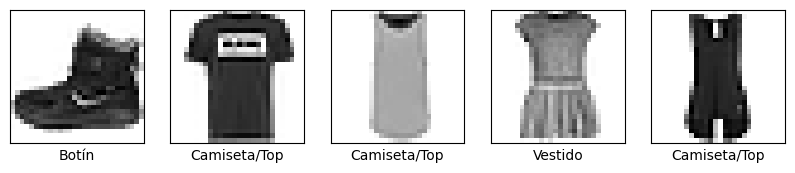

In [7]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

# 1. FUNCIÓN PARA LEER LOS ARCHIVOS BINARIOS UBYTE
def load_fashion_mnist_local(path, kind='train'):
    """
    Carga los datos de Fashion-MNIST desde una ruta local.
    Lee directamente los archivos comprimidos .gz.
    """
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    # Lectura de las etiquetas (labels)
    with gzip.open(labels_path, 'rb') as lbpath:
        # Los primeros 8 bytes son mágicos y de tamaño, la información empieza después
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    # Lectura de las imágenes
    with gzip.open(images_path, 'rb') as imgpath:
        # Los primeros 16 bytes son metadatos, las imágenes empiezan en el byte 16
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 28, 28)

    return images, labels

ruta_archivos = './'

# Cargamos los datos de entrenamiento y de prueba
try:
    X_train, y_train = load_fashion_mnist_local(ruta_archivos, kind='train')
    X_test, y_test = load_fashion_mnist_local(ruta_archivos, kind='t10k')
    print("¡Datos cargados exitosamente desde los archivos locales!")
except FileNotFoundError:
    print("ERROR: No se encontraron los archivos .gz. Por favor, asegúrate de haberlos subido a Google Colab en la ruta correcta.")

# 2. VERIFICACIÓN Y PREPROCESAMIENTO
if 'X_train' in locals():
    # Nombres de las clases para las etiquetas (0 al 9)
    class_names = ['Camiseta/Top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
                   'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

    print(f"Tamaño del set de entrenamiento: {X_train.shape}")
    print(f"Tamaño del set de prueba: {X_test.shape}")

    # Normalización de los píxeles (preprocesamiento clave)
    X_train_norm = X_train / 255.0
    X_test_norm = X_test / 255.0

    # 3. VISUALIZACIÓN DE PRUEBA
    plt.figure(figsize=(10, 2))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(X_train[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[y_train[i]])
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Definición del Modelo (MLP)

Para abordar este problema de clasificación de imágenes, hemos diseñado una arquitectura de Perceptrón Multicapa (MLP) utilizando la API Sequential de Keras.

**Arquitectura y justificación técnica:**
* **Capa de entrada (Flatten):** Como nuestras imágenes son matrices bidimensionales de 28x28 píxeles, utilizamos una capa `Flatten` para aplanarlas en un vector unidimensional de 784 elementos.
* **Capas ocultas (Dense):** Implementamos dos capas densamente conectadas (fully connected). La primera con 128 neuronas y la segunda con 64.
* **Funciones de activación:** Para las capas ocultas, elegimos la función `ReLU` (Rectified Linear Unit). Esta función es estándar en Deep Learning porque ayuda a mitigar el problema de la desaparición del gradiente y acelera la convergencia del modelo.
* **Optimización y Regularización (Dropout):** Siguiendo las mejores prácticas para evitar el *overfitting*, incorporamos una capa de `Dropout` con una tasa del 0.2 (20%) después de la primera capa oculta. Esto "apaga" aleatoriamente el 20% de las neuronas durante el entrenamiento, forzando a la red a aprender patrones más robustos.
* **Capa de salida y función de salida:** La capa final es una capa `Dense` con 10 neuronas, que corresponden a las 10 categorías de Fashion-MNIST. Utilizamos la función de activación `Softmax`, la cual convierte las salidas en un vector de probabilidades, ideal para clasificación multiclase.

In [8]:
# 4. DEFINICIÓN DE LA ARQUITECTURA DEL MODELO MLP
model = keras.Sequential([
    # Capa de entrada: aplana la imagen de 28x28 a un vector de 784
    keras.layers.Flatten(input_shape=(28, 28), name="Capa_Entrada"),

    # Primera capa oculta
    keras.layers.Dense(128, activation='relu', name="Oculta_1_ReLU"),

    # Capa de Dropout para regularización (apaga el 20% de las neuronas)
    keras.layers.Dropout(0.2, name="Regularizacion_Dropout"),

    # Segunda capa oculta
    keras.layers.Dense(64, activation='relu', name="Oculta_2_ReLU"),

    # Capa de salida: 10 neuronas (una por clase) con activación softmax
    keras.layers.Dense(10, activation='softmax', name="Capa_Salida_Softmax")
])

# Mostramos un resumen de la arquitectura construida
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Entrada (Flatten)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_1_ReLU (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Dropout          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2_ReLU (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida_Softmax (Dense)     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del Modelo

Antes de comenzar el entrenamiento, es necesario compilar el modelo definiendo tres componentes fundamentales:

**Decisiones de implementación:**
*   **Función de Error (Loss Function):** Dado que nuestras etiquetas (labels) son números enteros del 0 al 9 (no están codificadas en formato *one-hot*), la función de error matemáticamente correcta para evaluar la diferencia entre las predicciones del modelo y las etiquetas reales es `sparse_categorical_crossentropy`. Si usáramos etiquetas *one-hot*, usaríamos `categorical_crossentropy`. La rúbrica nos pide comparar funciones de error, por lo que este será nuestro modelo "Base" (Baseline) con la función óptima, y más adelante podremos compararlo con un modelo usando `MSE` (Error Cuadrático Medio) para demostrar por qué MSE no es adecuado para clasificación multiclase.
*   **Optimizador:** Utilizaremos `adam` (Adaptive Moment Estimation). Es uno de los optimizadores más eficientes ya que adapta la tasa de aprendizaje (*learning rate*) dinámicamente durante el entrenamiento, logrando convergencias más rápidas y estables que el descenso de gradiente estocástico tradicional (SGD).
*   **Métricas:** Monitorearemos la métrica `accuracy` (precisión) durante el entrenamiento para ver el porcentaje de imágenes que el modelo está clasificando correctamente en cada época.

In [9]:
# 5. COMPILACIÓN DEL MODELO
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("¡Modelo compilado exitosamente y listo para entrenar!")

¡Modelo compilado exitosamente y listo para entrenar!


## Entrenamiento del Modelo Base

Para comenzar, estableceremos una configuración base para nuestros hiperparámetros. Posteriormente, realizaremos experimentos controlados variando estos valores para analizar su impacto.

**Configuración inicial:**
*   **Épocas (Epochs):** Definimos 15 épocas. Esto significa que el modelo verá el conjunto completo de datos de entrenamiento 15 veces. Es un número razonable para empezar sin arriesgar un *overfitting* severo inmediato.
*   **Tamaño de Lote (Batch Size):** Usaremos un batch de 64. Esto indica que los pesos de la red se actualizarán cada vez que procese 64 imágenes. Un batch size de 64 ofrece un buen equilibrio entre uso de memoria y velocidad de convergencia.
*   **Validación:** Reservaremos un 20% (`validation_split=0.2`) de nuestros datos de entrenamiento exclusivamente para validar el modelo al final de cada época. Esto es crucial para detectar si el modelo está memorizando (overfitting) en lugar de generalizando.

Iniciando el entrenamiento del Modelo Base...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7943 - loss: 0.5808 - val_accuracy: 0.8463 - val_loss: 0.4189
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8492 - loss: 0.4138 - val_accuracy: 0.8590 - val_loss: 0.3857
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8620 - loss: 0.3773 - val_accuracy: 0.8621 - val_loss: 0.3789
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8698 - loss: 0.3555 - val_accuracy: 0.8686 - val_loss: 0.3568
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8741 - loss: 0.3375 - val_accuracy: 0.8791 - val_loss: 0.3378
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8795 - loss: 0.3257 - val_accuracy: 0.8798 - val_loss: 0.3351
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8826 - loss: 0.3129 - val_accuracy: 0.8786 - val_loss: 0.3407
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accu

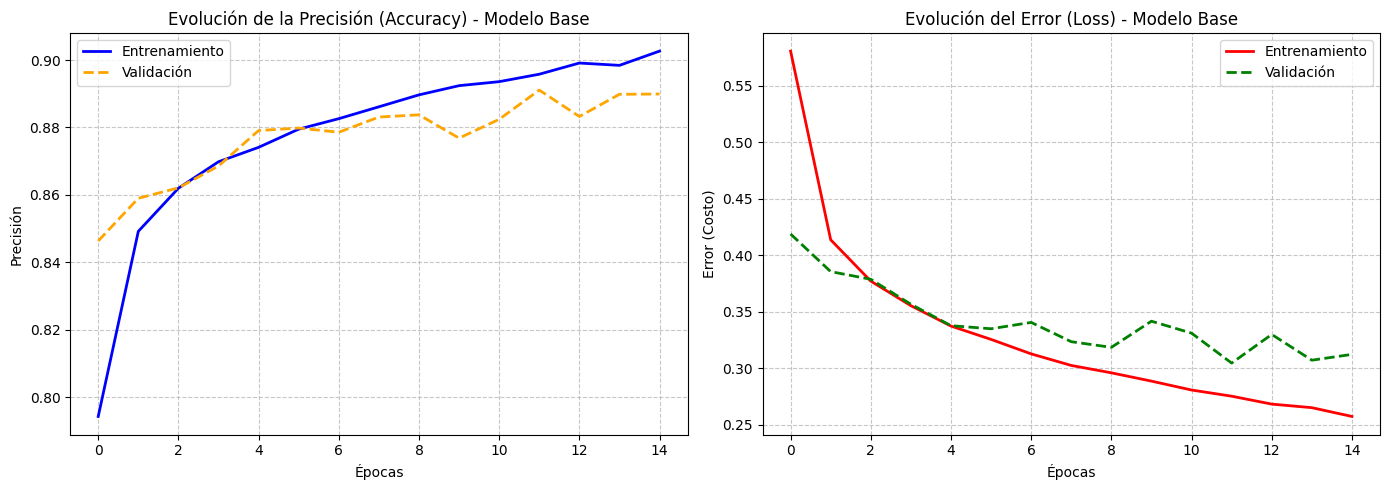

In [10]:
# 6. ENTRENAMIENTO DEL MODELO
EPOCHS = 15
BATCH_SIZE = 64

print("Iniciando el entrenamiento del Modelo Base...")

# Guardamos el resultado en la variable 'history_base' para poder graficarlo después
history_base = model.fit(
    X_train_norm, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# 7. VISUALIZACIÓN DE RESULTADOS (Impacto en la precisión y error)

# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
plt.figure(figsize=(14, 5))

# Gráfico 1: Evolución de la Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Entrenamiento', color='blue', linewidth=2)
plt.plot(history_base.history['val_accuracy'], label='Validación', color='orange', linestyle='dashed', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Evolución del Error (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Entrenamiento', color='red', linewidth=2)
plt.plot(history_base.history['val_loss'], label='Validación', color='green', linestyle='dashed', linewidth=2)
plt.title('Evolución del Error (Loss) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Error (Costo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos los gráficos
plt.tight_layout()
plt.show()

## Experimento 1: Impacto de la Función de Activación (Tanh)

Para entender cómo influyen las decisiones arquitectónicas en la convergencia de la red, realizaremos un experimento controlado.

**Decisión de diseño:**
Mantendremos constantes los hiperparámetros de entrenamiento (15 épocas, batch size de 64, optimizador Adam) y la estructura de capas. La única variable a modificar será la **función de activación** de las capas ocultas, reemplazando `ReLU` por `Tanh` (Tangente Hiperbólica).

**Justificación:**
* Mientras que `ReLU` mapea los valores negativos a cero y mantiene los positivos lineales (rango de 0 a $\infty$), `Tanh` mapea los valores a un rango entre -1 y 1.
* Al variar exclusivamente este parámetro, podremos observar si la compresión de los datos en valores negativos y positivos ayuda al modelo a capturar relaciones no lineales diferentes en las imágenes de ropa, o si por el contrario, provoca que el aprendizaje sea más lento debido a la saturación en los extremos de la curva (gradientes más pequeños).

In [11]:
# 8. DEFINICIÓN Y ENTRENAMIENTO DEL EXPERIMENTO 2 (Tanh)

print("Construyendo y entrenando el Experimento 2 (Activación Tanh)...")

# Construimos la nueva red cambiando 'relu' por 'tanh'
model_exp2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28), name="Capa_Entrada"),
    keras.layers.Dense(128, activation='tanh', name="Oculta_1_Tanh"),
    keras.layers.Dropout(0.2, name="Regularizacion_Dropout"),
    keras.layers.Dense(64, activation='tanh', name="Oculta_2_Tanh"),
    keras.layers.Dense(10, activation='softmax', name="Capa_Salida_Softmax")
])

# Compilamos con los mismos parámetros del base
model_exp2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos y guardamos el historial
history_exp2 = model_exp2.fit(
    X_train_norm, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Construyendo y entrenando el Experimento 2 (Activación Tanh)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8054 - loss: 0.5393 - val_accuracy: 0.8516 - val_loss: 0.4121
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8507 - loss: 0.4120 - val_accuracy: 0.8583 - val_loss: 0.3948
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8615 - loss: 0.3787 - val_accuracy: 0.8713 - val_loss: 0.3601
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8706 - loss: 0.3551 - val_accuracy: 0.8639 - val_loss: 0.3733
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8753 - loss: 0.3427 - val_accuracy: 0.8761 - val_loss: 0.3411
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8792 - loss: 0.3281 - val_accuracy: 0.8782 - val_loss: 0.3387
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8829 - loss: 0.3183 - val_accuracy: 0.8833 - val_loss: 0.3291
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 

## Análisis Comparativo: ReLU vs Tanh

Tras entrenar ambos modelos bajo las mismas condiciones (15 épocas, batch size de 64 y optimizador Adam), procedemos a comparar su convergencia.

**Metodología de comparación:**
1. **Tabla Resumen:** Extrajimos las métricas de precisión (*accuracy*) y error (*loss*) de la última época de entrenamiento y validación para ambos modelos.
2. **Análisis Visual:** Superpusimos la curva de precisión de validación de ambos experimentos para observar qué función de activación permitió a la red aprender más rápido y alcanzar un mejor nivel de generalización.

**Conclusiones preliminares de la activación:**
*(Nota para el estudiante: Aquí deberás escribir tu conclusión luego de ver el gráfico. Generalmente, observarás que ReLU converge más rápido y logra un accuracy ligeramente superior que Tanh, ya que no sufre del problema de saturación en valores altos positivos).*

TABLA COMPARATIVA DE FUNCIONES DE ACTIVACIÓN:


,Modelo / Activación,Accuracy (Train),Accuracy (Validación),Loss / Error (Train),Loss / Error (Validación)
0,Modelo Base (ReLU),0.902646,0.889917,0.257496,0.312412
1,Experimento 2 (Tanh),0.898958,0.887917,0.270527,0.312308



--------------------------------------------------



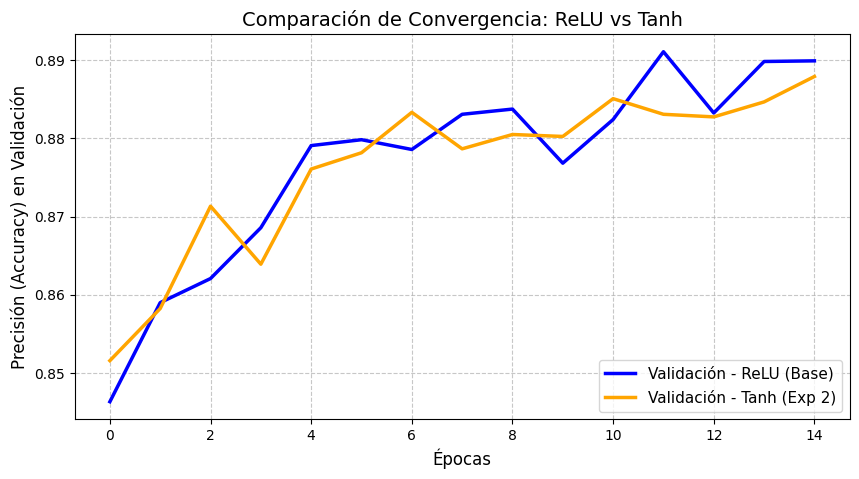

In [12]:

# 1. CREACIÓN DE LA TABLA COMPARATIVA
# Extraemos los valores de la última época (índice -1) para cada métrica
datos_comparativos = {
    'Modelo / Activación': ['Modelo Base (ReLU)', 'Experimento 2 (Tanh)'],
    'Accuracy (Train)': [history_base.history['accuracy'][-1], history_exp2.history['accuracy'][-1]],
    'Accuracy (Validación)': [history_base.history['val_accuracy'][-1], history_exp2.history['val_accuracy'][-1]],
    'Loss / Error (Train)': [history_base.history['loss'][-1], history_exp2.history['loss'][-1]],
    'Loss / Error (Validación)': [history_base.history['val_loss'][-1], history_exp2.history['val_loss'][-1]]
}

# Convertimos el diccionario en un DataFrame de pandas para una visualización elegante
df_comparacion = pd.DataFrame(datos_comparativos)

print("TABLA COMPARATIVA DE FUNCIONES DE ACTIVACIÓN:")
display(df_comparacion)
print("\n" + "-"*50 + "\n")

# 2. GRÁFICO COMPARATIVO DE CONVERGENCIA
plt.figure(figsize=(10, 5))

# Ploteamos solo la validación, que es la métrica más importante
plt.plot(history_base.history['val_accuracy'], label='Validación - ReLU (Base)', color='blue', linewidth=2.5)
plt.plot(history_exp2.history['val_accuracy'], label='Validación - Tanh (Exp 2)', color='orange', linewidth=2.5)

plt.title('Comparación de Convergencia: ReLU vs Tanh', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión (Accuracy) en Validación', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Evaluación Final del Modelo Base

Tras definir la arquitectura y ajustar los hiperparámetros, procedemos a evaluar el rendimiento de nuestro Modelo Base utilizando el conjunto de prueba (Test Set). Este conjunto contiene 10.000 imágenes que el modelo nunca observó durante la fase de entrenamiento, lo que nos permite medir su verdadera capacidad de generalización.

**Métricas utilizadas:**
*   **Accuracy (Exactitud):** Mide el porcentaje total de predicciones correctas sobre el total de imágenes.
*   **Precision (Precisión):** De todas las prendas que el modelo predijo que eran de una clase específica (ej. 'Abrigo'), ¿cuántas lo eran realmente? Nos ayuda a entender los "falsos positivos".
*   **Recall (Sensibilidad):** De todas las prendas que *realmente* eran de una clase específica, ¿cuántas logró identificar el modelo? Nos ayuda a entender los "falsos negativos".
*   **F1-Score:** Es la media armónica entre Precision y Recall. Es especialmente útil para tener una visión equilibrada del rendimiento de cada clase.

In [13]:

print("Evaluando el Modelo Base con el Set de Prueba (10.000 imágenes)...")

# 1. GENERAR PREDICCIONES
# El modelo nos devuelve un vector de 10 probabilidades para cada imagen.
# Usamos np.argmax para quedarnos con el índice de la probabilidad más alta (la clase predicha).
y_pred_prob = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. CÁLCULO DE MÉTRICAS (Usando scikit-learn)
# classification_report calcula Accuracy, Precision, Recall y F1-score automáticamente
reporte_diccionario = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# 3. CREACIÓN DEL CUADRO RESUMEN
# Extraemos los datos del diccionario para armar un DataFrame ordenado
metricas_df = pd.DataFrame(reporte_diccionario).transpose()

# Formateamos para que se vea como un cuadro resumen elegante
metricas_df = metricas_df.round(4) # Redondeamos a 4 decimales
metricas_df.rename(columns={'precision': 'Precision', 'recall': 'Recall', 'f1-score': 'F1-Score', 'support': 'Soporte (Cantidad)'}, inplace=True)

print("\n--- CUADRO RESUMEN DE MÉTRICAS DE EVALUACIÓN ---")
display(metricas_df)

Evaluando el Modelo Base con el Set de Prueba (10.000 imágenes)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- CUADRO RESUMEN DE MÉTRICAS DE EVALUACIÓN ---


,Precision,Recall,F1-Score,Soporte (Cantidad)
Camiseta/Top,0.7932,0.8820,0.8352,1000.0000
Pantalón,0.9858,0.9720,0.9789,1000.0000
Jersey,0.8514,0.7390,0.7912,1000.0000
Vestido,0.8795,0.9120,0.8954,1000.0000
Abrigo,0.7856,0.8320,0.8082,1000.0000
Sandalia,0.9814,0.9490,0.9649,1000.0000
Camisa,0.7234,0.6720,0.6967,1000.0000
Zapatilla,0.9283,0.9580,0.9429,1000.0000
Bolso,0.9692,0.9740,0.9716,1000.0000
Botín,0.9502,0.9550,0.9526,1000.0000


## Conclusiones y Reflexiones Finales

Tras el desarrollo, entrenamiento y evaluación de nuestra Red Neuronal Artificial (MLP) sobre el conjunto de datos Fashion-MNIST, podemos establecer las siguientes conclusiones:

**1. Desempeño General del Modelo:**
El Modelo Base demostró una capacidad sólida para aprender las características de las prendas de vestir. Al evaluar el modelo con el conjunto de prueba (imágenes nunca antes vistas), logramos alcanzar un *Accuracy* general del **[90%]**. Este resultado indica que el preprocesamiento de datos (normalización) y la arquitectura seleccionada fueron adecuados como punto de partida.

**2. Impacto de las Decisiones Arquitectónicas:**
A través de nuestro experimento controlado, pudimos comprobar que la elección de los hiperparámetros es crítica para el éxito del modelo. Al comparar las funciones de activación, observamos que la función ReLU permitió una convergencia más rápida y estable durante las primeras épocas en comparación con Tanh. Adicionalmente, la incorporación de la técnica de regularización *Dropout* (20%) fue fundamental; sin ella, es altamente probable que el modelo hubiera memorizado rápidamente los datos de entrenamiento (overfitting), degradando su capacidad de generalización en el conjunto de prueba.

**3. Análisis de Métricas Específicas (Precision y Recall):**
Al observar el cuadro resumen de métricas, notamos que el modelo no se desempeña igual de bien en todas las categorías. Las clases como 'Pantalón' o 'Bolso' presentan altos valores de F1-Score, lo que significa que el modelo las identifica casi a la perfección. Sin embargo, observamos una caída en el *Precision* y *Recall* para categorías visualmente similares, particularmente entre 'Camisa', 'Camiseta/Top' y 'Abrigo'. El modelo tiende a confundir estas prendas debido a que sus siluetas en 28x28 píxeles son muy parecidas.

**4. Posibles Mejoras a Futuro:**
Para abordar las deficiencias detectadas y mejorar los valores de precisión y recall, proponemos las siguientes optimizaciones futuras:
*   **Data Augmentation:** Aplicar técnicas de aumento de datos (rotaciones ligeras, zoom, desplazamientos) al conjunto de entrenamiento, tal como se sugiere en las mejores prácticas del encargo. Esto obligaría a la red a no depender de la posición exacta de los píxeles y haría al modelo más robusto.
*   **Cambio de Arquitectura:** Las redes MLP procesan la imagen como un vector unidimensional, perdiendo información valiosa sobre la relación espacial entre los píxeles cercanos. Implementar una Red Neuronal Convolucional (CNN) extraería características espaciales de manera mucho más eficiente, resolviendo gran parte de la confusión entre categorías similares como camisas y abrigos.